# Homework 2

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$.

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

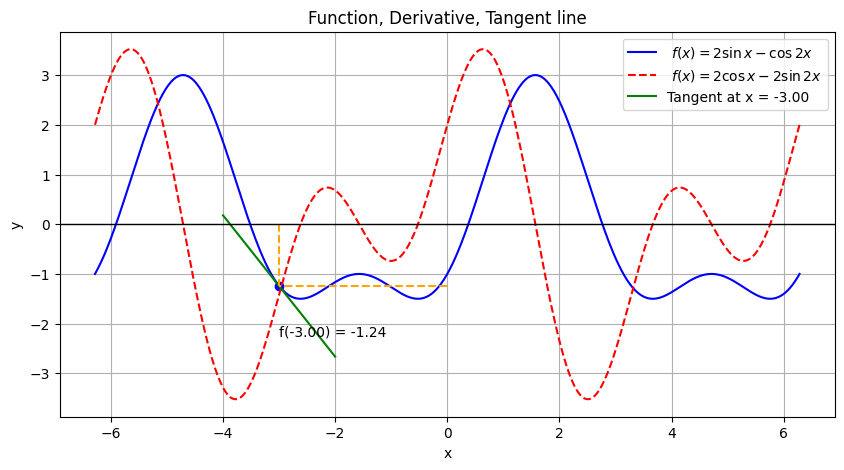

In [89]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

def beauty_derivative_plot(point_x):
    plt.figure(figsize = (10, 5))

    px=point_x
    py=2*np.sin(point_x)-np.cos(2*point_x)
    x = np.linspace(-2*np.pi,2*np.pi,500)
    plt.plot(x,2*np.sin(x)-np.cos(2*x),"b-",label =r" $f(x) = 2\sin x - \cos{2x}$")
    plt.plot(px, py, "bo")
    plt.plot(x,2*np.cos(x)+2*np.sin(2*x),"r--",label =r" $f(x) = 2\cos x - 2\sin{2x}$")

    x_tan = np.linspace(point_x-1, point_x+1, 500)
    k = 2*np.cos(point_x)+2*np.sin(2*point_x)
    b = py-k*point_x
    plt.plot(x_tan,k*x_tan+b, "g-",label = r"Tangent at x = %0.2f"%px)
    plt.text(px, py-1, "f(%0.2f) = %0.2f"%(px, py),fontsize=10 )

    plt.plot([point_x, point_x], [0, py], linestyle='--', color='orange')
    plt.plot([0, point_x], [py, py], linestyle='--', color='orange')

    plt.legend(loc="best")
    plt.title("Function, Derivative, Tangent line")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(True)
    plt.show()

beauty_derivative_plot(-3)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

Downloading...
From: https://drive.google.com/uc?id=15WG5kwiq72NdaFpTlmWv0BTpM3ywwJGD
To: /content/populations.txt
100%|██████████| 532/532 [00:00<00:00, 1.35MB/s]


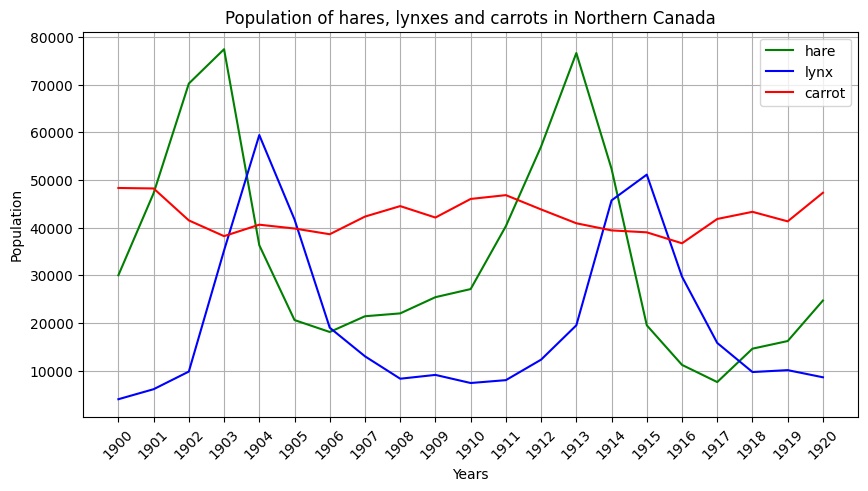

In [90]:
import gdown

gdown.download("https://drive.google.com/uc?id=15WG5kwiq72NdaFpTlmWv0BTpM3ywwJGD", "populations.txt", quiet = False)
data = np.loadtxt('populations.txt')

year = data[:, 0]
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

plt.figure(figsize = (10, 5))
plt.plot(year, hares, "g-", label = "hare")
plt.plot(year, lynxes, "b-", label = "lynx")
plt.plot(year, carrots, "r-", label = "carrot")

plt.legend(loc="best")
plt.xlabel("Years")
plt.ylabel("Population")
plt.title("Population of hares, lynxes and carrots in Northern Canada")
plt.xticks(year, rotation=45)
plt.grid(True)

- Find which year each species had the largest population. Mark these years in the plot of populations.

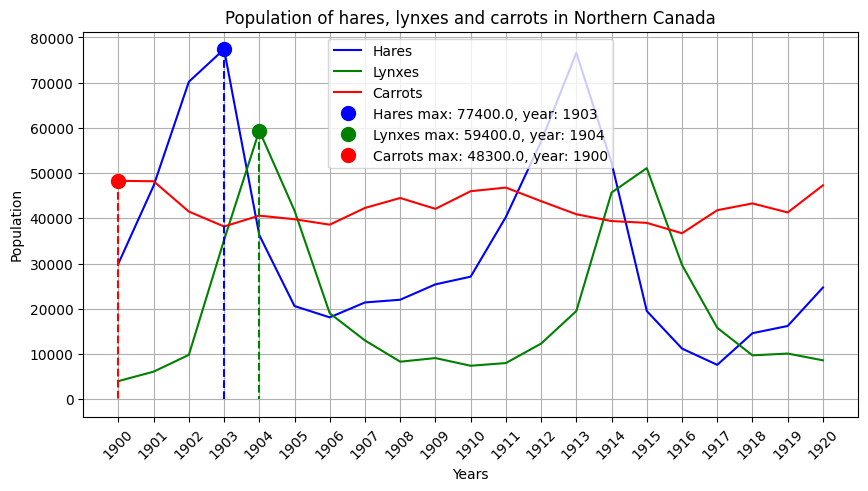

In [91]:
max_h_index = np.argmax(hares)
max_l_index = np.argmax(lynxes)
max_c_index = np.argmax(carrots)

max_h_year = year[max_h_index]
max_l_year = year[max_l_index]
max_c_year = year[max_c_index]

max_hares = hares[max_h_index]
max_lynxes = lynxes[max_l_index]
max_carrots = carrots[max_c_index]

plt.figure(figsize=(10, 5))
plt.plot(year, hares, "b-", label = "Hares")
plt.plot(year, lynxes, "g-", label = "Lynxes")
plt.plot(year, carrots, "r-", label = "Carrots")
plt.plot(max_h_year, max_hares, "bo", markersize = 10,
         label = f"Hares max: {max_hares}, year: {int(max_h_year)}")
plt.plot(max_l_year, max_lynxes, "go", markersize = 10,
         label = f"Lynxes max: {max_lynxes}, year: {int(max_l_year)}")
plt.plot(max_c_year, max_carrots, "ro", markersize = 10,
         label = f"Carrots max: {max_carrots}, year: {int(max_c_year)}")
plt.plot([max_h_year, max_h_year, ], [max_hares, 0], "b--")
plt.plot([max_l_year, max_l_year], [max_lynxes, 0], "g--")
plt.plot([max_c_year, max_c_year], [max_carrots, 0], "r--")

plt.xticks(year, rotation=45)
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Population")
plt.title("Population of hares, lynxes and carrots in Northern Canada")
plt.legend()
plt.show()

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

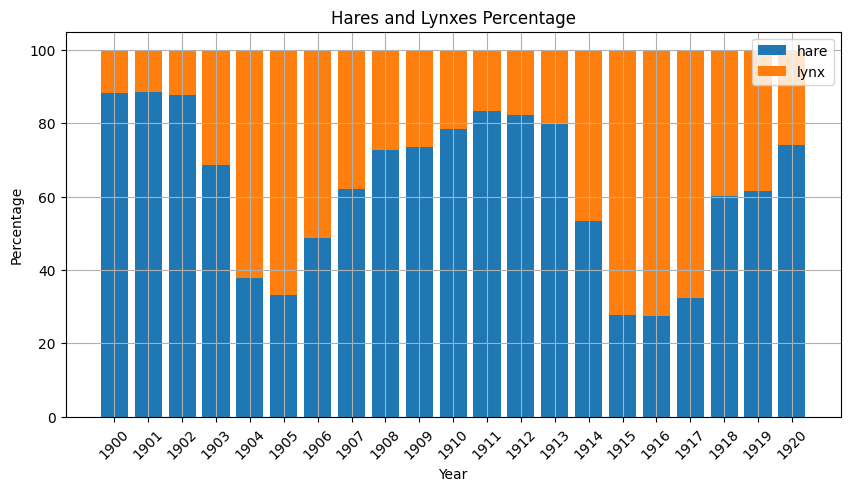

In [92]:
h_percent = (hares / (hares + lynxes)) * 100
l_percent = (lynxes / (hares + lynxes)) * 100


plt.figure(figsize=(10, 5))

plt.bar(year, h_percent, label="hare")
plt.bar(year, l_percent, bottom=h_percent, label="lynx")

plt.grid(True)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title("Hares and Lynxes Percentage")
plt.xticks(year, rotation=45)
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

Mean - Hares: 34080.95238095238 ; Std, Lynxes: 20166.666666666668 ; Std, Carrots: 42400.0
Std - Hares: 20897.906458089667 ; Std, Lynxes: 16254.591536908763 ; Std, Carrots: 3322.5062255844787


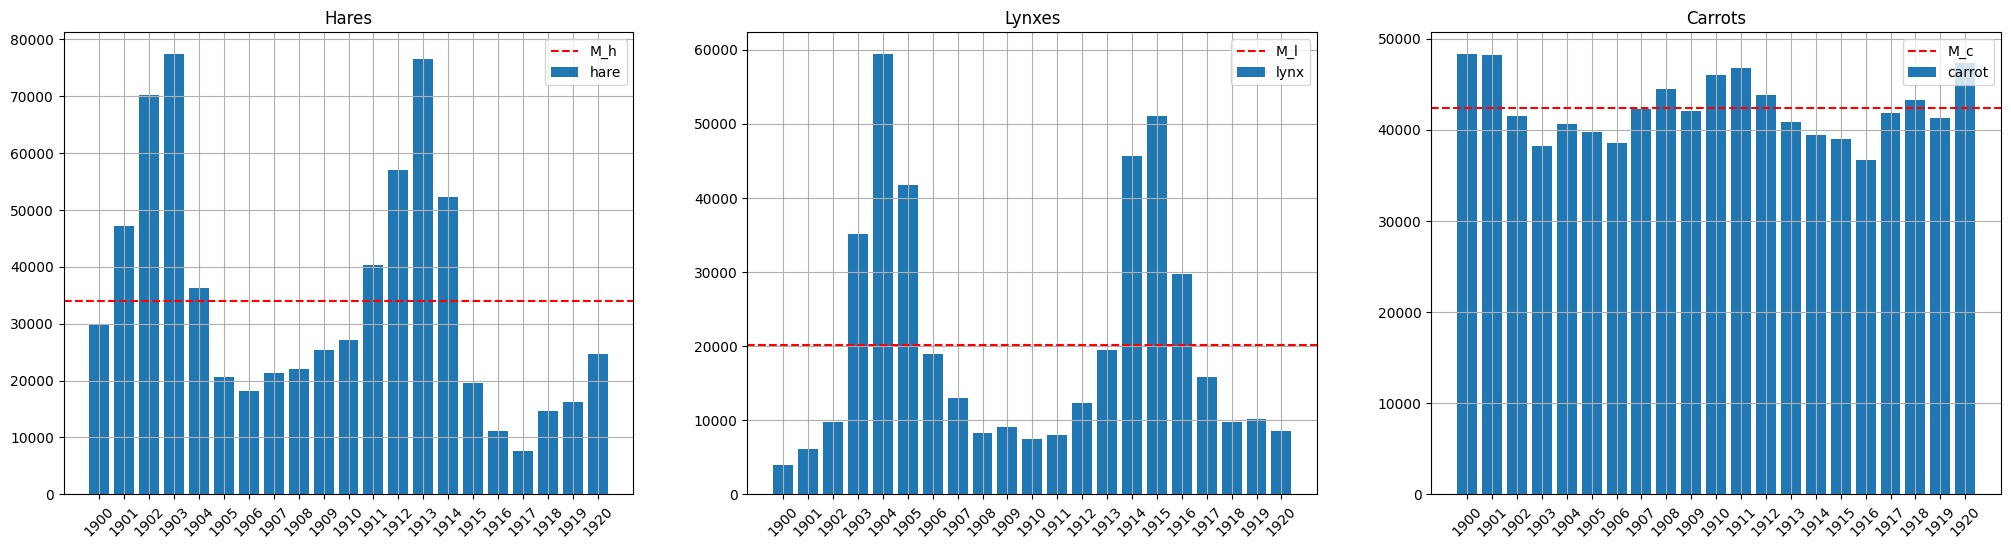

In [93]:
M_h = hares.mean()
M_l = lynxes.mean()
M_c = carrots.mean()

Std_h = hares.std()
Std_l = lynxes.std()
Std_c = carrots.std()

print("Mean - Hares:", M_h, "; Std, Lynxes:", M_l,"; Std, Carrots:", M_c)
print("Std - Hares:", Std_h, "; Std, Lynxes:", Std_l,"; Std, Carrots:", Std_c)


plt.figure(figsize=(25, 6))

plt.subplot(131)
plt.bar(year, hares, label="hare")
plt.xticks(year, rotation=45)
plt.axhline(M_h, linestyle='--', color='red', label = "M_h")
plt.title("Hares")
plt.grid(True)
plt.legend()

plt.subplot(132)
plt.bar(year, lynxes, label="lynx")
plt.xticks(year, rotation=45)
plt.axhline(M_l, linestyle='--', color='red', label = "M_l")
plt.title("Lynxes")
plt.grid(True)
plt.legend()

plt.subplot(133)
plt.bar(year, carrots, label="carrot")
plt.xticks(year, rotation=45)
plt.axhline(M_c, linestyle='--', color='red', label = "M_c")
plt.title("Carrots")
plt.grid(True)
plt.legend()

plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']



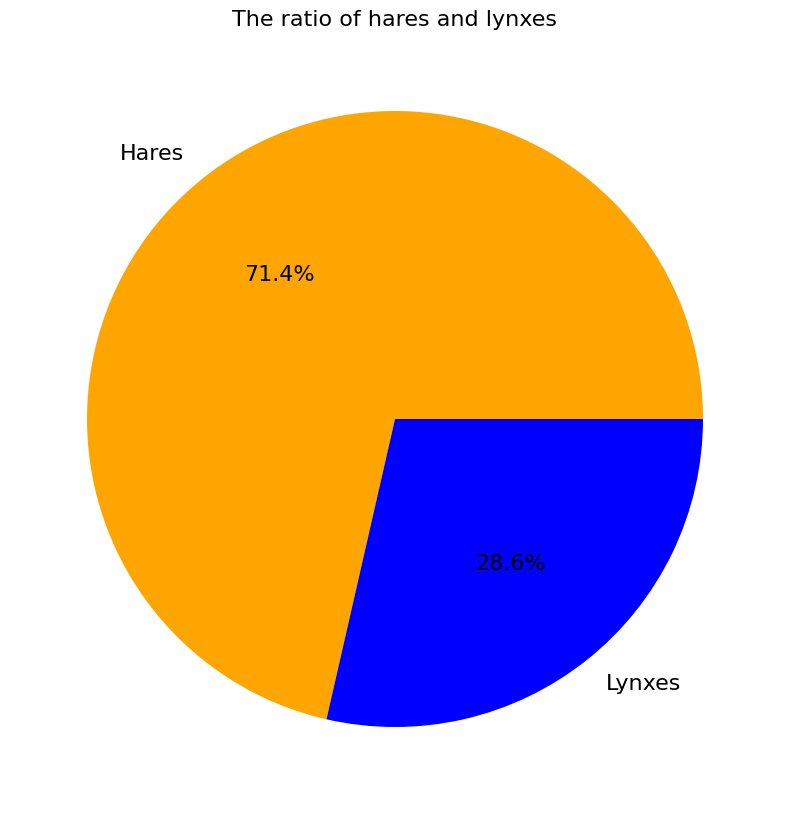

In [94]:
H_L_list = np.where(hares > lynxes, "H", "L").tolist()
print(H_L_list)
print()

h_count = np.sum(hares > lynxes)
l_count = np.sum(hares <= lynxes)

plt.figure(figsize = (10, 10))
plt.pie([h_count, l_count], labels = ["Hares", "Lynxes"], autopct = "%1.1f%%",
        textprops = {"fontsize": 16}, colors = ["orange", "blue"])
plt.title("The ratio of hares and lynxes", fontsize = 16)
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

Correlation coefficient: 0.07189206073535571



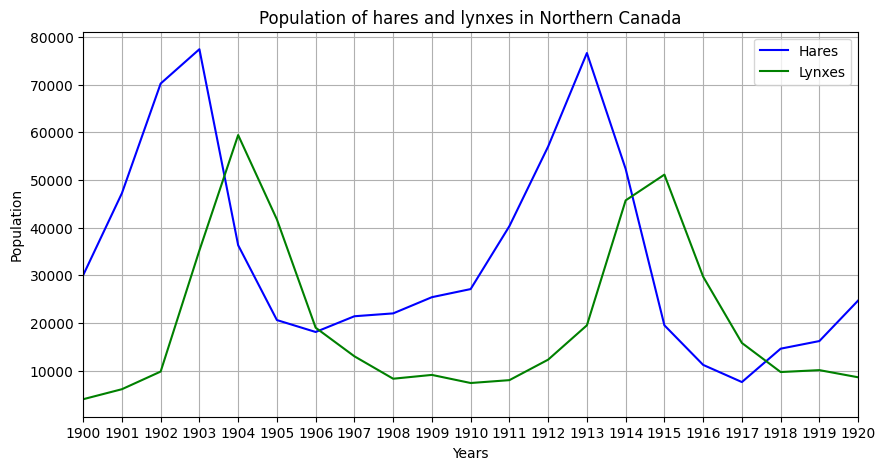

In [95]:
corr = np.corrcoef(hares, lynxes)[0, 1]
print("Correlation coefficient:", corr)
print()

plt.figure(figsize = (10, 5))
plt.plot(year, hares, "b-", label = "Hares")
plt.plot(year, lynxes, "g-", label = "Lynxes")

plt.xticks(year)
plt.xlim(1900, 1920)
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Population")
plt.title("Population of hares and lynxes in Northern Canada")
plt.legend()
plt.show()

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

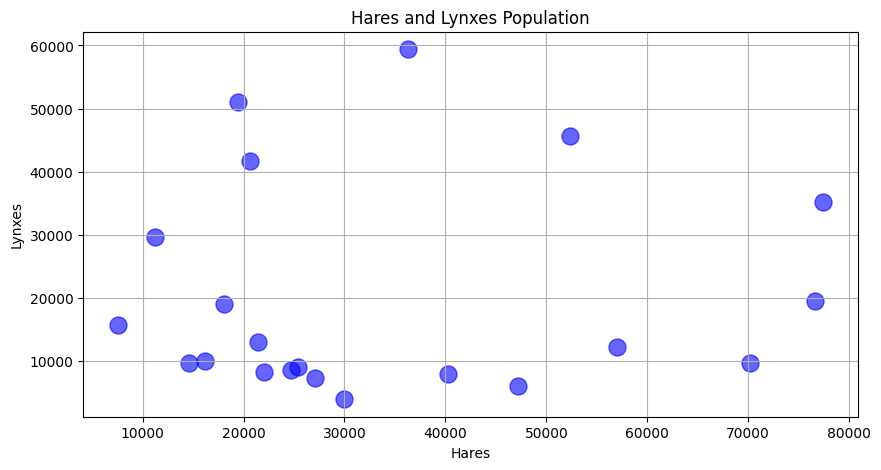

In [96]:
plt.figure(figsize = (10, 5))
plt.scatter(hares, lynxes, color = "blue", s = 150, alpha = 0.6)
plt.xlabel("Hares")
plt.ylabel("Lynxes")
plt.title("Hares and Lynxes Population")
plt.grid(True)
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [97]:
real_value = hares[-1]
estimated_value = np.median(hares[:-1])
error = abs(real_value - estimated_value)
ratio = error / real_value

print("Real value:", real_value)
print("Estimated value:", estimated_value)
print(f"Ratio of the error to the true value: {ratio:.2%}")

Real value: 24700.0
Estimated value: 26250.0
Ratio of the error to the true value: 6.28%


Я решил использовать медиану в качестве оценки, так как она, в отличие от среднего, устойчива к выбросам, которые определенно есть в данных.